<a href="https://colab.research.google.com/github/Fu-Pei-Yin/Deep-Generative-Mode/blob/week7/%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

使用裝置: cpu
股價預測：LSTM vs Transformer
下載 2330.TW 資料...
計算技術指標...
資料形狀: (1181, 21)
日期範圍: 2020-02-27 00:00:00 到 2024-12-30 00:00:00
訓練集: (920, 30, 20), 驗證集: (115, 30, 20), 測試集: (116, 30, 20)

訓練 LSTM 模型
Epoch 5/30 - Train Loss: 1.018556, Val Loss: 1.632401, LR: 0.000100
Epoch 10/30 - Train Loss: 0.979345, Val Loss: 1.756972, LR: 0.000100
Epoch 15/30 - Train Loss: 0.960824, Val Loss: 1.899201, LR: 0.000100
Epoch 20/30 - Train Loss: 0.956907, Val Loss: 1.984613, LR: 0.000100
Epoch 25/30 - Train Loss: 0.971282, Val Loss: 2.020337, LR: 0.000100
Epoch 30/30 - Train Loss: 0.942730, Val Loss: 2.157257, LR: 0.000100

LSTM 測試結果:
標準化空間 - MSE: 2.555641, MAE: 1.218505, RMSE: 1.598637
原始尺度 - MSE: 0.000709, MAE: 0.020296, RMSE: 0.026627

訓練 Transformer 模型
Epoch 5/30 - Train Loss: 1.019990, Val Loss: 1.836394, LR: 0.000238
Epoch 10/30 - Train Loss: 0.952630, Val Loss: 1.848178, LR: 0.000030
Epoch 15/30 - Train Loss: 0.957582, Val Loss: 2.042304, LR: 0.000284
Epoch 20/30 - Train Loss: 0.974242, Val Loss: 2

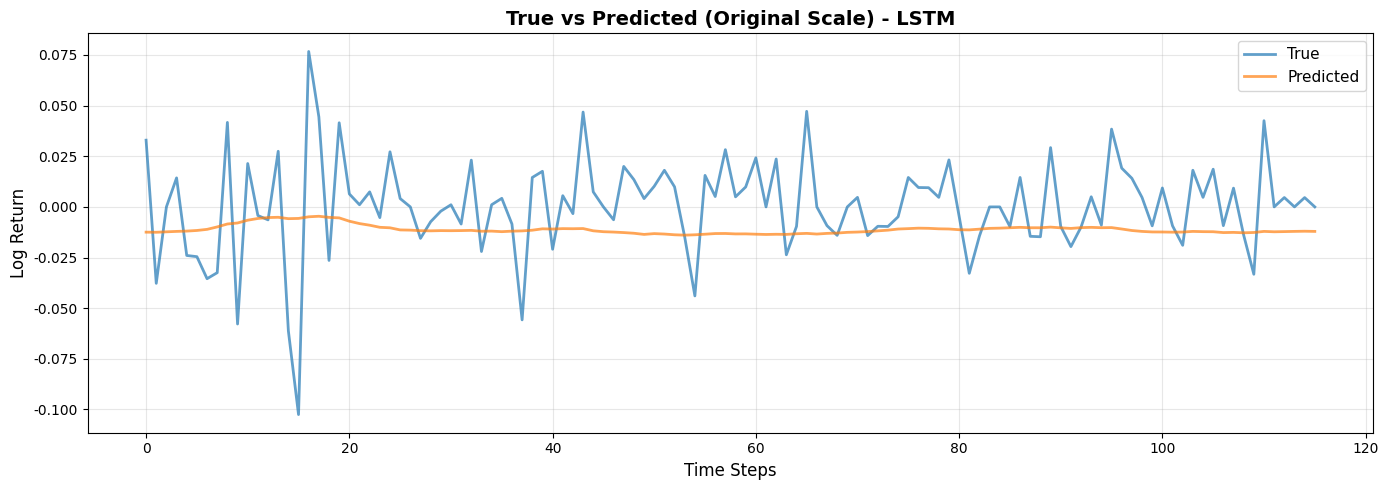

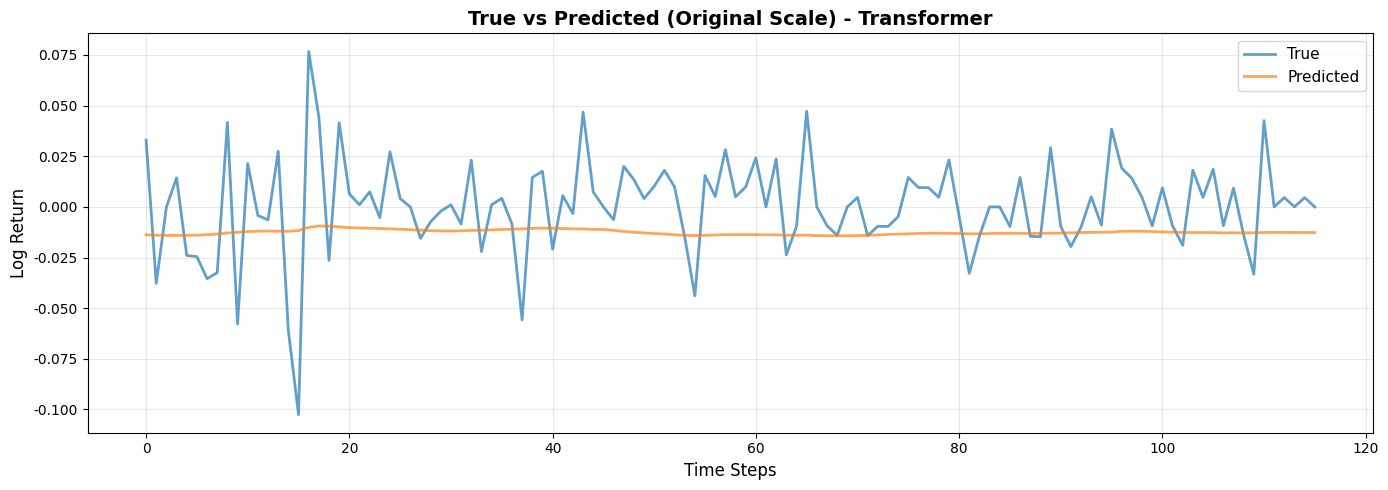

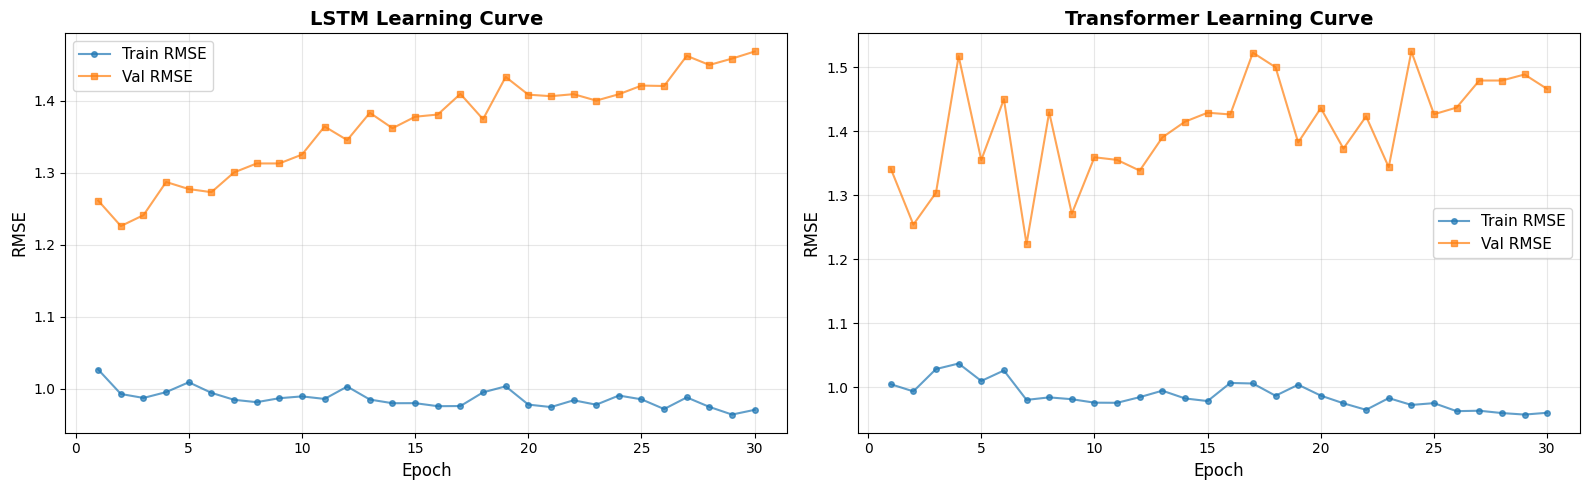

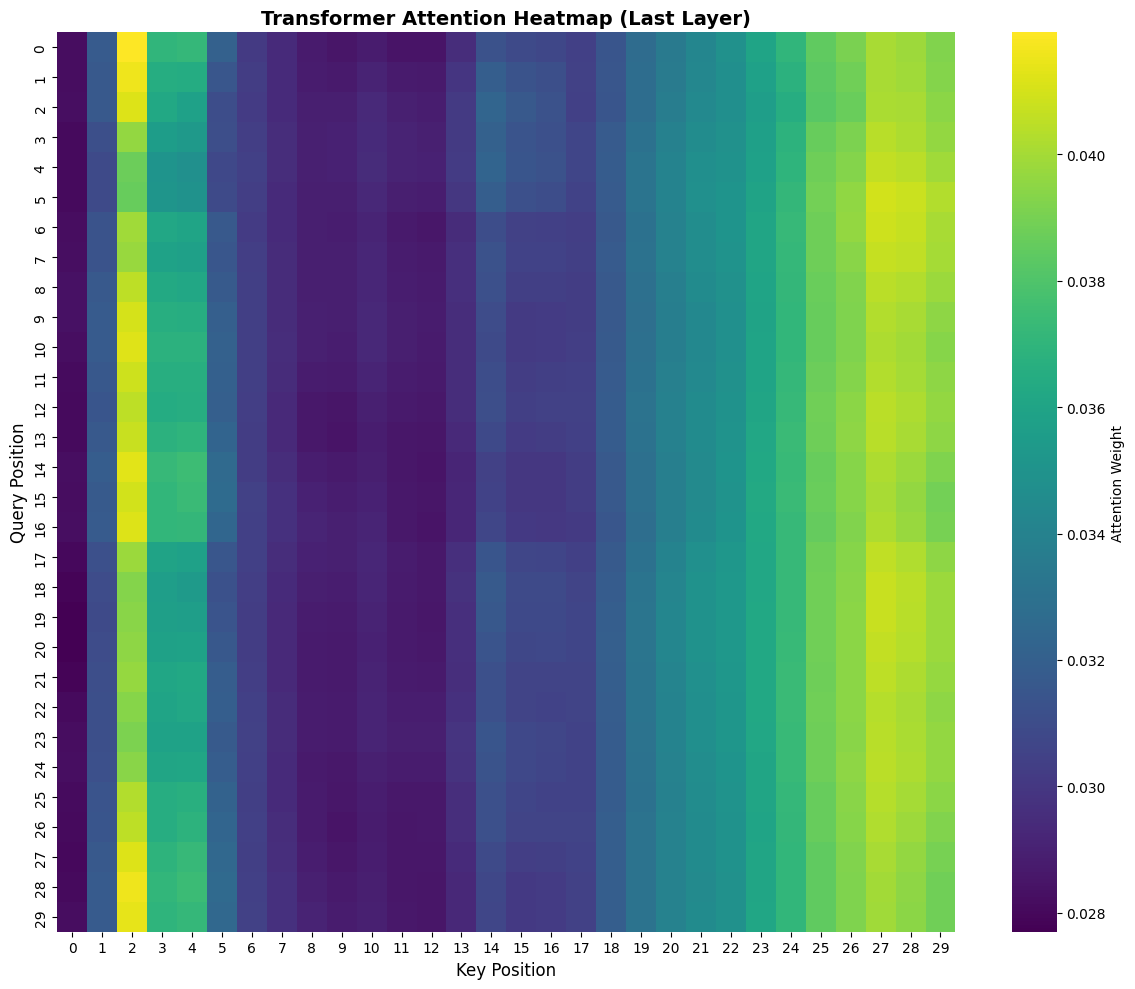


技術指標比較實驗（LSTM vs Transformer）

測試 趨勢型 指標...
訓練集: (920, 30, 12), 驗證集: (115, 30, 12), 測試集: (116, 30, 12)
  訓練 LSTM with 趨勢型...
Epoch 5/30 - Train Loss: 0.975614, Val Loss: 1.477053, LR: 0.000100
Epoch 10/30 - Train Loss: 0.989242, Val Loss: 1.532418, LR: 0.000100
Epoch 15/30 - Train Loss: 0.974662, Val Loss: 1.548496, LR: 0.000100
Epoch 20/30 - Train Loss: 0.964063, Val Loss: 1.678265, LR: 0.000100
Epoch 25/30 - Train Loss: 0.981665, Val Loss: 1.732953, LR: 0.000100
Epoch 30/30 - Train Loss: 1.018504, Val Loss: 1.840924, LR: 0.000100
  訓練 Transformer with 趨勢型...
Epoch 5/30 - Train Loss: 1.004526, Val Loss: 2.064358, LR: 0.000238
Epoch 10/30 - Train Loss: 0.967448, Val Loss: 1.586260, LR: 0.000030
Epoch 15/30 - Train Loss: 1.001301, Val Loss: 1.607886, LR: 0.000284
Epoch 20/30 - Train Loss: 0.970183, Val Loss: 1.779043, LR: 0.000197
Epoch 25/30 - Train Loss: 0.964298, Val Loss: 2.345550, LR: 0.000083
Epoch 30/30 - Train Loss: 0.986541, Val Loss: 2.105023, LR: 0.000008
趨勢型 結果:
  LSTM - RM

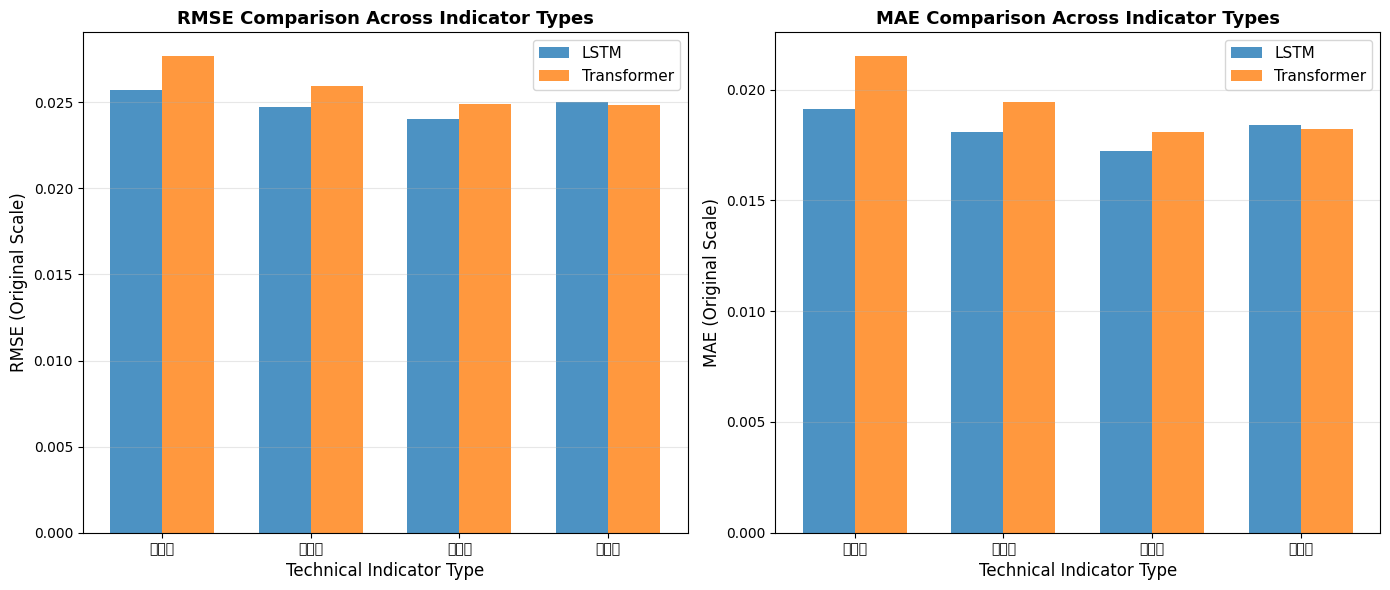

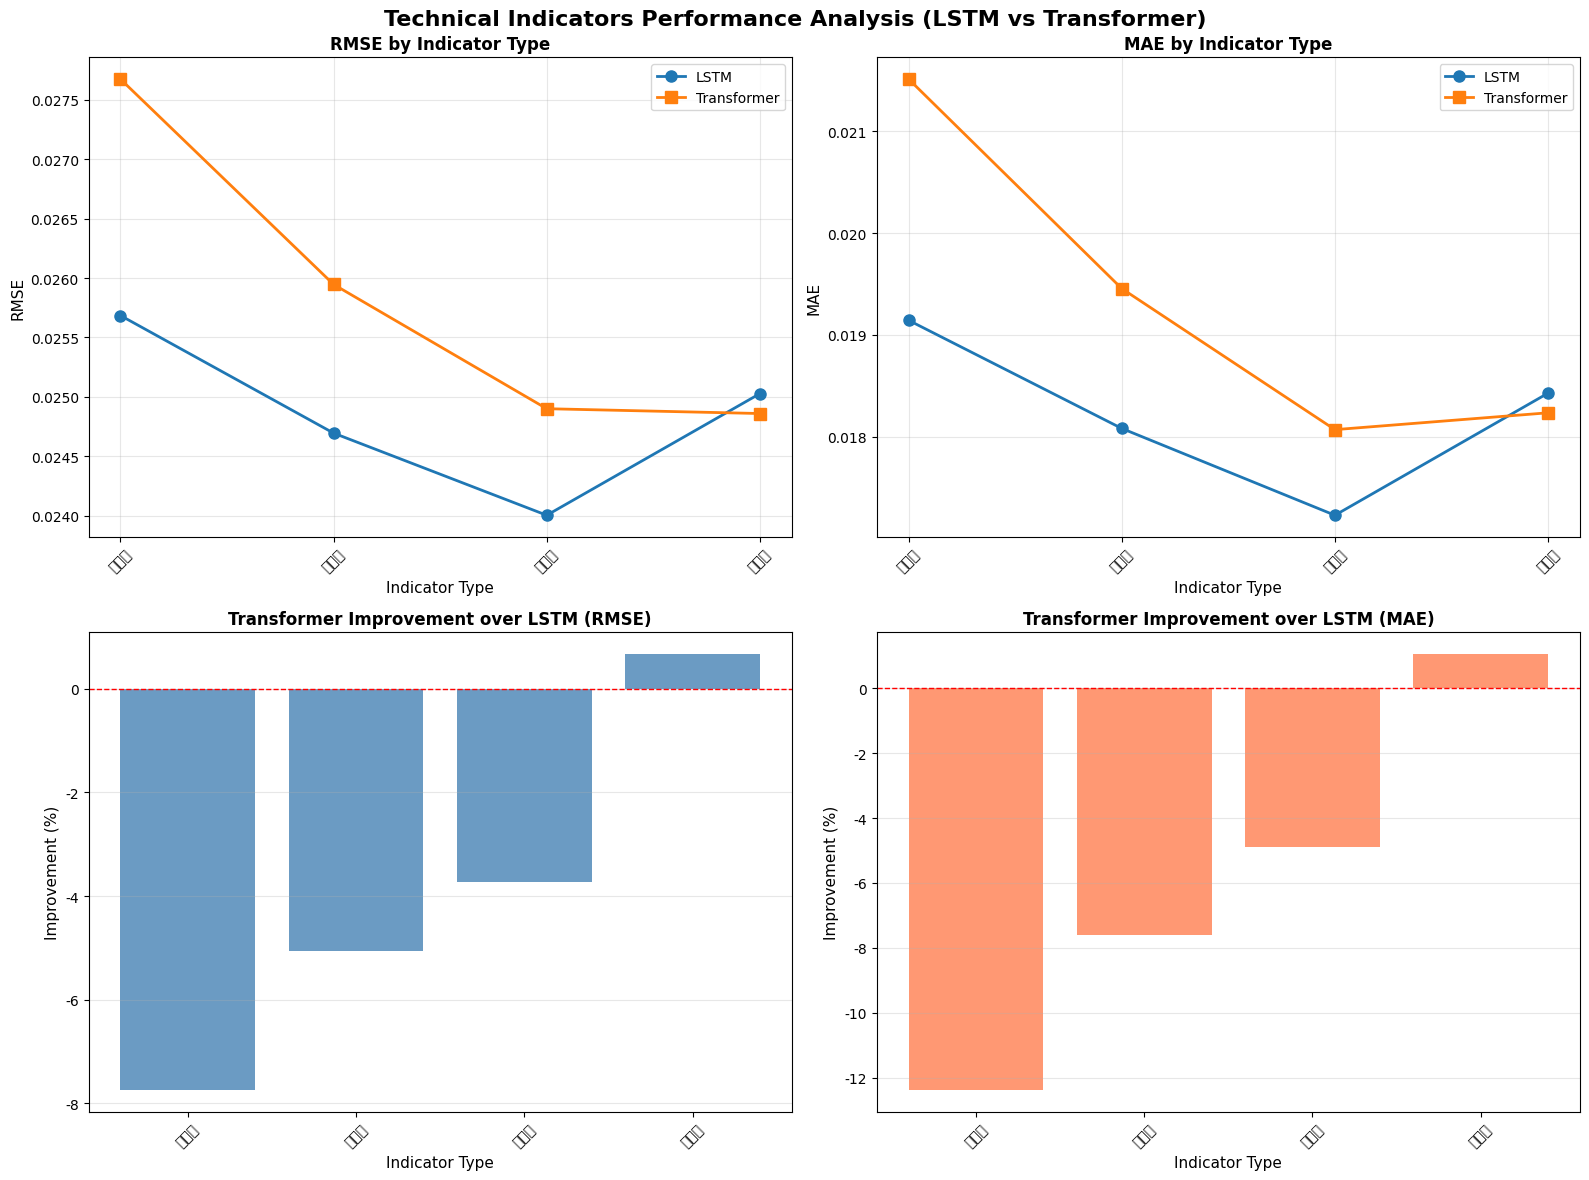


實驗結果摘要

【主模型比較】
Model           Scaled RMSE     Scaled MAE      Original RMSE   Original MAE   
---------------------------------------------------------------------------
LSTM            1.598637        1.218505        0.026627        0.020296       
Transformer     1.625645        1.250593        0.027077        0.020830       

【技術指標比較 - LSTM】
Indicator       RMSE            MAE            
---------------------------------------------
趨勢型             0.025685        0.019142       
震盪型             0.024695        0.018080       
波動型             0.024003        0.017227       
量能型             0.025027        0.018427       

【技術指標比較 - Transformer】
Indicator       RMSE            MAE            
---------------------------------------------
趨勢型             0.027675        0.021512       
震盪型             0.025946        0.019454       
波動型             0.024900        0.018068       
量能型             0.024860        0.018234       

【Transformer 相對 LSTM 的改善率 (%)】
Indicator       RMSE I

In [6]:
"""
利用 LSTM 與 Transformer 預測股價時間序列
完整實作程式 - 可在 Google Colab 運行
"""

# ========== 1. 安裝與導入套件 ==========
!pip install yfinance ta -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設定隨機種子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

# ========== 2. 資料下載與技術指標計算 ==========
def download_and_prepare_data(ticker='2330.TW', start='2020-01-01', end='2024-12-31'):
    """下載股價資料並計算技術指標"""
    print(f"下載 {ticker} 資料...")
    df = yf.download(ticker, start=start, end=end, progress=False)

    # 處理多層索引（如果存在）
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    # 基本欄位
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

    # 確保所有欄位都是一維的
    for col in df.columns:
        if df[col].ndim > 1:
            df[col] = df[col].values.flatten()

    # 計算技術指標
    print("計算技術指標...")

    # 確保 Close 是一維 Series
    close_prices = df['Close'].squeeze() if hasattr(df['Close'], 'squeeze') else df['Close']
    high_prices = df['High'].squeeze() if hasattr(df['High'], 'squeeze') else df['High']
    low_prices = df['Low'].squeeze() if hasattr(df['Low'], 'squeeze') else df['Low']
    volume = df['Volume'].squeeze() if hasattr(df['Volume'], 'squeeze') else df['Volume']

    # 趨勢型指標
    df['SMA_5'] = ta.trend.sma_indicator(close_prices, window=5)
    df['SMA_20'] = ta.trend.sma_indicator(close_prices, window=20)
    df['EMA_12'] = ta.trend.ema_indicator(close_prices, window=12)
    df['EMA_26'] = ta.trend.ema_indicator(close_prices, window=26)

    # MACD
    macd = ta.trend.MACD(close_prices)
    df['MACD'] = macd.macd()
    df['MACD_SIGNAL'] = macd.macd_signal()
    df['MACD_HIST'] = macd.macd_diff()

    # 震盪型指標
    df['RSI_14'] = ta.momentum.rsi(close_prices, window=14)
    df['STOCH'] = ta.momentum.stoch(high_prices, low_prices, close_prices)

    # 波動型指標
    bollinger = ta.volatility.BollingerBands(close_prices)
    df['BB_HIGH'] = bollinger.bollinger_hband()
    df['BB_LOW'] = bollinger.bollinger_lband()
    df['BB_MID'] = bollinger.bollinger_mavg()
    df['ATR'] = ta.volatility.average_true_range(high_prices, low_prices, close_prices)

    # 量能型指標
    df['OBV'] = ta.volume.on_balance_volume(close_prices, volume)
    df['VOL_SMA'] = volume.rolling(window=20).mean()

    # 計算 log return 作為目標
    df['logret'] = np.log(close_prices).diff()

    # 移除 NaN
    df = df.dropna()

    print(f"資料形狀: {df.shape}")
    print(f"日期範圍: {df.index[0]} 到 {df.index[-1]}")

    return df

# ========== 3. 資料集類別 ==========
class StockDataset(Dataset):
    """股價時間序列資料集"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(data, target, lookback=30):
    """創建時間序列樣本"""
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(target[i+lookback])
    return np.array(X), np.array(y)

def prepare_data_splits(df, feature_cols, target_col='logret', lookback=30,
                       train_ratio=0.8, val_ratio=0.1):
    """準備訓練/驗證/測試集（時間序列切分）"""
    # 提取特徵和目標
    features = df[feature_cols].values
    target = df[target_col].values

    # 創建序列
    X, y = create_sequences(features, target, lookback)

    # 時間序列切分
    n = len(X)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # 標準化（只用訓練集 fit）
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    print(f"訓練集: {X_train_scaled.shape}, 驗證集: {X_val_scaled.shape}, 測試集: {X_test_scaled.shape}")

    return (X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled,
            X_test_scaled, y_test_scaled, scaler_X, scaler_y, y_test)

# ========== 4. LSTM 模型 ==========
class LSTMModel(nn.Module):
    """LSTM 基線模型"""
    def __init__(self, input_size, hidden_size=128, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 取最後時間步
        last_output = lstm_out[:, -1, :]
        normalized = self.layer_norm(last_output)
        output = self.fc(normalized)
        return output.squeeze(-1)

# ========== 5. Transformer 模型 ==========
class PositionalEncoding(nn.Module):
    """正弦位置編碼"""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    """Transformer Encoder-only 模型"""
    def __init__(self, input_size, d_model=128, nhead=8, num_layers=2,
                 dim_feedforward=256, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
        self.last_attention = None

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        # 儲存最後一層注意力權重
        for i, layer in enumerate(self.transformer_encoder.layers):
            if i == len(self.transformer_encoder.layers) - 1:
                # 最後一層，提取注意力
                attn_output, attn_weights = layer.self_attn(x, x, x, need_weights=True, average_attn_weights=True)
                self.last_attention = attn_weights
                x = layer.norm1(x + layer.dropout1(attn_output))
                ff_output = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
                x = layer.norm2(x + layer.dropout2(ff_output))
            else:
                x = layer(x)

        # Mean pooling
        x = x.mean(dim=1)
        output = self.fc(x)
        return output.squeeze(-1)

# ========== 6. 訓練函數 ==========
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-4,
                model_type='lstm', warmup_ratio=0.1):
    """訓練模型"""
    criterion = nn.MSELoss()

    if model_type == 'transformer':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        # Warmup
        total_steps = epochs * len(train_loader)
        warmup_steps = int(total_steps * warmup_ratio)
        # CosineAnnealingWarmRestarts
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = None
        warmup_steps = 0

    train_losses = []
    val_losses = []
    current_step = 0

    for epoch in range(epochs):
        # 訓練階段
        model.train()
        train_loss = 0
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Warmup for Transformer
            if model_type == 'transformer' and current_step < warmup_steps:
                lr_scale = min(1., float(current_step + 1) / warmup_steps)
                for pg in optimizer.param_groups:
                    pg['lr'] = lr * lr_scale

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            current_step += 1

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 驗證階段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # 更新 scheduler（在 warmup 後）
        if scheduler and model_type == 'transformer' and current_step >= warmup_steps:
            scheduler.step()

        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {current_lr:.6f}")

    return train_losses, val_losses

def evaluate_model(model, test_loader, scaler_y):
    """評估模型"""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            predictions.extend(output.cpu().numpy())
            actuals.extend(y_batch.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # 標準化空間的指標
    mse_scaled = mean_squared_error(actuals, predictions)
    mae_scaled = mean_absolute_error(actuals, predictions)
    rmse_scaled = np.sqrt(mse_scaled)

    # 反標準化到原始尺度
    predictions_original = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = scaler_y.inverse_transform(actuals.reshape(-1, 1)).flatten()

    mse_original = mean_squared_error(actuals_original, predictions_original)
    mae_original = mean_absolute_error(actuals_original, predictions_original)
    rmse_original = np.sqrt(mse_original)

    return {
        'scaled': {'MSE': mse_scaled, 'MAE': mae_scaled, 'RMSE': rmse_scaled},
        'original': {'MSE': mse_original, 'MAE': mae_original, 'RMSE': rmse_original},
        'predictions_scaled': predictions,
        'actuals_scaled': actuals,
        'predictions_original': predictions_original,
        'actuals_original': actuals_original
    }

# ========== 7. 視覺化函數 ==========
def plot_predictions(actuals, predictions, title, model_name):
    """繪製預測結果"""
    plt.figure(figsize=(14, 5))
    plt.plot(actuals, label='True', alpha=0.7, linewidth=2)
    plt.plot(predictions, label='Predicted', alpha=0.7, linewidth=2)
    plt.title(f'{title} - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Log Return', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_prediction.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_learning_curves_comparison(lstm_train, lstm_val, trans_train, trans_val):
    """繪製 LSTM 和 Transformer 學習曲線對比"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    epochs = range(1, len(lstm_train) + 1)

    # LSTM 學習曲線
    axes[0].plot(epochs, [np.sqrt(l) for l in lstm_train], label='Train RMSE',
                 marker='o', markersize=4, alpha=0.7)
    axes[0].plot(epochs, [np.sqrt(l) for l in lstm_val], label='Val RMSE',
                 marker='s', markersize=4, alpha=0.7)
    axes[0].set_title('LSTM Learning Curve', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('RMSE', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Transformer 學習曲線
    axes[1].plot(epochs, [np.sqrt(l) for l in trans_train], label='Train RMSE',
                 marker='o', markersize=4, alpha=0.7)
    axes[1].plot(epochs, [np.sqrt(l) for l in trans_val], label='Val RMSE',
                 marker='s', markersize=4, alpha=0.7)
    axes[1].set_title('Transformer Learning Curve', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('RMSE', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('learning_curves_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_attention_heatmap(model, test_loader, sample_idx=0):
    """繪製注意力熱圖"""
    model.eval()
    with torch.no_grad():
        for i, (X_batch, _) in enumerate(test_loader):
            if i == sample_idx:
                X_batch = X_batch.to(device)
                _ = model(X_batch)
                attention = model.last_attention[0].cpu().numpy()

                plt.figure(figsize=(12, 10))
                sns.heatmap(attention, cmap='viridis', cbar_kws={'label': 'Attention Weight'})
                plt.title('Transformer Attention Heatmap (Last Layer)', fontsize=14, fontweight='bold')
                plt.xlabel('Key Position', fontsize=12)
                plt.ylabel('Query Position', fontsize=12)
                plt.tight_layout()
                plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
                plt.show()
                break

# ========== 8. 主程式 ==========
def main():
    print("=" * 60)
    print("股價預測：LSTM vs Transformer")
    print("=" * 60)

    # 下載資料
    df = download_and_prepare_data('2330.TW', '2020-01-01', '2024-12-31')

    # 定義特徵欄位（包含四類技術指標）
    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        # 趨勢型
        'SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
        # 震盪型
        'RSI_14', 'STOCH',
        # 波動型
        'BB_HIGH', 'BB_LOW', 'BB_MID', 'ATR',
        # 量能型
        'OBV', 'VOL_SMA'
    ]

    # 準備資料
    lookback = 30
    (X_train, y_train, X_val, y_val, X_test, y_test,
     scaler_X, scaler_y, y_test_original) = prepare_data_splits(
        df, feature_cols, 'logret', lookback
    )

    # 創建 DataLoader
    batch_size = 64
    train_dataset = StockDataset(X_train, y_train)
    val_dataset = StockDataset(X_val, y_val)
    test_dataset = StockDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    input_size = X_train.shape[-1]

    # ========== LSTM 模型 ==========
    print("\n" + "=" * 60)
    print("訓練 LSTM 模型")
    print("=" * 60)
    lstm_model = LSTMModel(input_size, hidden_size=128, dropout=0.1).to(device)
    lstm_train_losses, lstm_val_losses = train_model(
        lstm_model, train_loader, val_loader, epochs=30, lr=1e-4, model_type='lstm'
    )

    lstm_results = evaluate_model(lstm_model, test_loader, scaler_y)
    print("\nLSTM 測試結果:")
    print(f"標準化空間 - MSE: {lstm_results['scaled']['MSE']:.6f}, "
          f"MAE: {lstm_results['scaled']['MAE']:.6f}, "
          f"RMSE: {lstm_results['scaled']['RMSE']:.6f}")
    print(f"原始尺度 - MSE: {lstm_results['original']['MSE']:.6f}, "
          f"MAE: {lstm_results['original']['MAE']:.6f}, "
          f"RMSE: {lstm_results['original']['RMSE']:.6f}")

    # ========== Transformer 模型 ==========
    print("\n" + "=" * 60)
    print("訓練 Transformer 模型")
    print("=" * 60)
    transformer_model = TransformerModel(
        input_size, d_model=128, nhead=8, num_layers=2,
        dim_feedforward=256, dropout=0.1
    ).to(device)

    transformer_train_losses, transformer_val_losses = train_model(
        transformer_model, train_loader, val_loader, epochs=30,
        lr=3e-4, model_type='transformer', warmup_ratio=0.1
    )

    transformer_results = evaluate_model(transformer_model, test_loader, scaler_y)
    print("\nTransformer 測試結果:")
    print(f"標準化空間 - MSE: {transformer_results['scaled']['MSE']:.6f}, "
          f"MAE: {transformer_results['scaled']['MAE']:.6f}, "
          f"RMSE: {transformer_results['scaled']['RMSE']:.6f}")
    print(f"原始尺度 - MSE: {transformer_results['original']['MSE']:.6f}, "
          f"MAE: {transformer_results['original']['MAE']:.6f}, "
          f"RMSE: {transformer_results['original']['RMSE']:.6f}")

    # ========== 視覺化 ==========
    print("\n" + "=" * 60)
    print("生成視覺化圖表")
    print("=" * 60)

    # 預測結果對比
    plot_predictions(
        lstm_results['actuals_original'],
        lstm_results['predictions_original'],
        'True vs Predicted (Original Scale)', 'LSTM'
    )

    plot_predictions(
        transformer_results['actuals_original'],
        transformer_results['predictions_original'],
        'True vs Predicted (Original Scale)', 'Transformer'
    )

    # 學習曲線對比
    plot_learning_curves_comparison(
        lstm_train_losses, lstm_val_losses,
        transformer_train_losses, transformer_val_losses
    )

    # 注意力熱圖
    plot_attention_heatmap(transformer_model, test_loader, sample_idx=0)

    # ========== 技術指標比較實驗（四類指標 × 兩種模型）==========
    print("\n" + "=" * 60)
    print("技術指標比較實驗（LSTM vs Transformer）")
    print("=" * 60)

    indicator_groups = {
        '趨勢型': ['SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_SIGNAL', 'MACD_HIST'],
        '震盪型': ['RSI_14', 'STOCH'],
        '波動型': ['BB_HIGH', 'BB_LOW', 'BB_MID', 'ATR'],
        '量能型': ['OBV', 'VOL_SMA']
    }

    base_features = ['Open', 'High', 'Low', 'Close', 'Volume']
    indicator_results_lstm = {}
    indicator_results_transformer = {}

    for group_name, indicators in indicator_groups.items():
        print(f"\n測試 {group_name} 指標...")
        test_features = base_features + indicators

        (X_train_ind, y_train_ind, X_val_ind, y_val_ind, X_test_ind, y_test_ind,
         scaler_X_ind, scaler_y_ind, _) = prepare_data_splits(
            df, test_features, 'logret', lookback
        )

        train_dataset_ind = StockDataset(X_train_ind, y_train_ind)
        val_dataset_ind = StockDataset(X_val_ind, y_val_ind)
        test_dataset_ind = StockDataset(X_test_ind, y_test_ind)

        train_loader_ind = DataLoader(train_dataset_ind, batch_size=batch_size, shuffle=True)
        val_loader_ind = DataLoader(val_dataset_ind, batch_size=batch_size)
        test_loader_ind = DataLoader(test_dataset_ind, batch_size=batch_size)

        # 測試 LSTM
        print(f"  訓練 LSTM with {group_name}...")
        lstm_ind = LSTMModel(len(test_features), hidden_size=128, dropout=0.1).to(device)
        _, _ = train_model(
            lstm_ind, train_loader_ind, val_loader_ind, epochs=30,
            lr=1e-4, model_type='lstm'
        )
        results_lstm = evaluate_model(lstm_ind, test_loader_ind, scaler_y_ind)
        indicator_results_lstm[group_name] = results_lstm

        # 測試 Transformer
        print(f"  訓練 Transformer with {group_name}...")
        trans_ind = TransformerModel(
            len(test_features), d_model=128, nhead=8, num_layers=2,
            dim_feedforward=256, dropout=0.1
        ).to(device)
        _, _ = train_model(
            trans_ind, train_loader_ind, val_loader_ind, epochs=30,
            lr=3e-4, model_type='transformer', warmup_ratio=0.1
        )
        results_trans = evaluate_model(trans_ind, test_loader_ind, scaler_y_ind)
        indicator_results_transformer[group_name] = results_trans

        print(f"{group_name} 結果:")
        print(f"  LSTM - RMSE: {results_lstm['original']['RMSE']:.6f}, "
              f"MAE: {results_lstm['original']['MAE']:.6f}")
        print(f"  Transformer - RMSE: {results_trans['original']['RMSE']:.6f}, "
              f"MAE: {results_trans['original']['MAE']:.6f}")

    # 繪製技術指標比較圖（RMSE）
    plt.figure(figsize=(14, 6))
    groups = list(indicator_results_lstm.keys())
    lstm_rmse = [indicator_results_lstm[g]['original']['RMSE'] for g in groups]
    trans_rmse = [indicator_results_transformer[g]['original']['RMSE'] for g in groups]
    lstm_mae = [indicator_results_lstm[g]['original']['MAE'] for g in groups]
    trans_mae = [indicator_results_transformer[g]['original']['MAE'] for g in groups]

    x = np.arange(len(groups))
    width = 0.35

    plt.subplot(1, 2, 1)
    plt.bar(x - width/2, lstm_rmse, width, label='LSTM', alpha=0.8)
    plt.bar(x + width/2, trans_rmse, width, label='Transformer', alpha=0.8)
    plt.xlabel('Technical Indicator Type', fontsize=12)
    plt.ylabel('RMSE (Original Scale)', fontsize=12)
    plt.title('RMSE Comparison Across Indicator Types', fontsize=13, fontweight='bold')
    plt.xticks(x, groups, fontsize=10)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3, axis='y')

    plt.subplot(1, 2, 2)
    plt.bar(x - width/2, lstm_mae, width, label='LSTM', alpha=0.8)
    plt.bar(x + width/2, trans_mae, width, label='Transformer', alpha=0.8)
    plt.xlabel('Technical Indicator Type', fontsize=12)
    plt.ylabel('MAE (Original Scale)', fontsize=12)
    plt.title('MAE Comparison Across Indicator Types', fontsize=13, fontweight='bold')
    plt.xticks(x, groups, fontsize=10)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('indicator_comparison_lstm_vs_transformer.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 繪製詳細的技術指標效果分析圖
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Technical Indicators Performance Analysis (LSTM vs Transformer)',
                 fontsize=16, fontweight='bold')

    # 1. RMSE 比較
    axes[0, 0].plot(groups, lstm_rmse, marker='o', label='LSTM', linewidth=2, markersize=8)
    axes[0, 0].plot(groups, trans_rmse, marker='s', label='Transformer', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Indicator Type', fontsize=11)
    axes[0, 0].set_ylabel('RMSE', fontsize=11)
    axes[0, 0].set_title('RMSE by Indicator Type', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. MAE 比較
    axes[0, 1].plot(groups, lstm_mae, marker='o', label='LSTM', linewidth=2, markersize=8)
    axes[0, 1].plot(groups, trans_mae, marker='s', label='Transformer', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Indicator Type', fontsize=11)
    axes[0, 1].set_ylabel('MAE', fontsize=11)
    axes[0, 1].set_title('MAE by Indicator Type', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. 改善率分析（Transformer vs LSTM）
    improvement_rmse = [(lstm_rmse[i] - trans_rmse[i]) / lstm_rmse[i] * 100 for i in range(len(groups))]
    improvement_mae = [(lstm_mae[i] - trans_mae[i]) / lstm_mae[i] * 100 for i in range(len(groups))]

    axes[1, 0].bar(groups, improvement_rmse, alpha=0.8, color='steelblue')
    axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[1, 0].set_xlabel('Indicator Type', fontsize=11)
    axes[1, 0].set_ylabel('Improvement (%)', fontsize=11)
    axes[1, 0].set_title('Transformer Improvement over LSTM (RMSE)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3, axis='y')
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].bar(groups, improvement_mae, alpha=0.8, color='coral')
    axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[1, 1].set_xlabel('Indicator Type', fontsize=11)
    axes[1, 1].set_ylabel('Improvement (%)', fontsize=11)
    axes[1, 1].set_title('Transformer Improvement over LSTM (MAE)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3, axis='y')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('indicator_detailed_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========== 生成結果摘要表格 ==========
    print("\n" + "=" * 60)
    print("實驗結果摘要")
    print("=" * 60)

    print("\n【主模型比較】")
    print(f"{'Model':<15} {'Scaled RMSE':<15} {'Scaled MAE':<15} {'Original RMSE':<15} {'Original MAE':<15}")
    print("-" * 75)
    print(f"{'LSTM':<15} {lstm_results['scaled']['RMSE']:<15.6f} {lstm_results['scaled']['MAE']:<15.6f} "
          f"{lstm_results['original']['RMSE']:<15.6f} {lstm_results['original']['MAE']:<15.6f}")
    print(f"{'Transformer':<15} {transformer_results['scaled']['RMSE']:<15.6f} {transformer_results['scaled']['MAE']:<15.6f} "
          f"{transformer_results['original']['RMSE']:<15.6f} {transformer_results['original']['MAE']:<15.6f}")

    print("\n【技術指標比較 - LSTM】")
    print(f"{'Indicator':<15} {'RMSE':<15} {'MAE':<15}")
    print("-" * 45)
    for group in groups:
        print(f"{group:<15} {indicator_results_lstm[group]['original']['RMSE']:<15.6f} "
              f"{indicator_results_lstm[group]['original']['MAE']:<15.6f}")

    print("\n【技術指標比較 - Transformer】")
    print(f"{'Indicator':<15} {'RMSE':<15} {'MAE':<15}")
    print("-" * 45)
    for group in groups:
        print(f"{group:<15} {indicator_results_transformer[group]['original']['RMSE']:<15.6f} "
              f"{indicator_results_transformer[group]['original']['MAE']:<15.6f}")

    print("\n【Transformer 相對 LSTM 的改善率 (%)】")
    print(f"{'Indicator':<15} {'RMSE Improvement':<20} {'MAE Improvement':<20}")
    print("-" * 55)
    for i, group in enumerate(groups):
        print(f"{group:<15} {improvement_rmse[i]:<20.2f} {improvement_mae[i]:<20.2f}")

    print("\n" + "=" * 60)
    print("所有實驗完成！")
    print("=" * 60)
    print("\n生成的圖表檔案：")
    print("1. LSTM_prediction.png - LSTM 預測結果")
    print("2. Transformer_prediction.png - Transformer 預測結果")
    print("3. learning_curves_comparison.png - 學習曲線對比")
    print("4. attention_heatmap.png - 注意力熱圖")
    print("5. indicator_comparison_lstm_vs_transformer.png - 技術指標比較")
    print("6. indicator_detailed_analysis.png - 詳細技術指標分析")

    # 返回結果供報告使用
    return {
        'lstm': lstm_results,
        'transformer': transformer_results,
        'indicators_lstm': indicator_results_lstm,
        'indicators_transformer': indicator_results_transformer,
        'improvement_rmse': improvement_rmse,
        'improvement_mae': improvement_mae
    }

# 執行主程式
if __name__ == '__main__':
    results = main()

使用裝置: cpu
股價預測：LSTM vs Transformer（完整作業版本）
下載 2330.TW 資料...
計算技術指標...
資料形狀: (1181, 21)
日期範圍: 2020-02-27 00:00:00 到 2024-12-30 00:00:00

實驗 1: 使用 logret 作為目標
訓練集: (920, 30, 20), 驗證集: (115, 30, 20), 測試集: (116, 30, 20)

訓練 LSTM 模型（logret 目標）
Epoch 5/30 - Train Loss: 1.018556, Val Loss: 1.632401, LR: 0.000100
Epoch 10/30 - Train Loss: 0.979345, Val Loss: 1.756972, LR: 0.000100
Epoch 15/30 - Train Loss: 0.960824, Val Loss: 1.899201, LR: 0.000100
Epoch 20/30 - Train Loss: 0.956907, Val Loss: 1.984613, LR: 0.000100
Epoch 25/30 - Train Loss: 0.971282, Val Loss: 2.020337, LR: 0.000100
Epoch 30/30 - Train Loss: 0.942730, Val Loss: 2.157257, LR: 0.000100

訓練 Transformer 模型（logret 目標）
Epoch 5/30 - Train Loss: 1.019990, Val Loss: 1.836394, LR: 0.000238
Epoch 10/30 - Train Loss: 0.952630, Val Loss: 1.848178, LR: 0.000030
Epoch 15/30 - Train Loss: 0.957582, Val Loss: 2.042304, LR: 0.000284
Epoch 20/30 - Train Loss: 0.974242, Val Loss: 2.062901, LR: 0.000197
Epoch 25/30 - Train Loss: 0.951195, Val Los

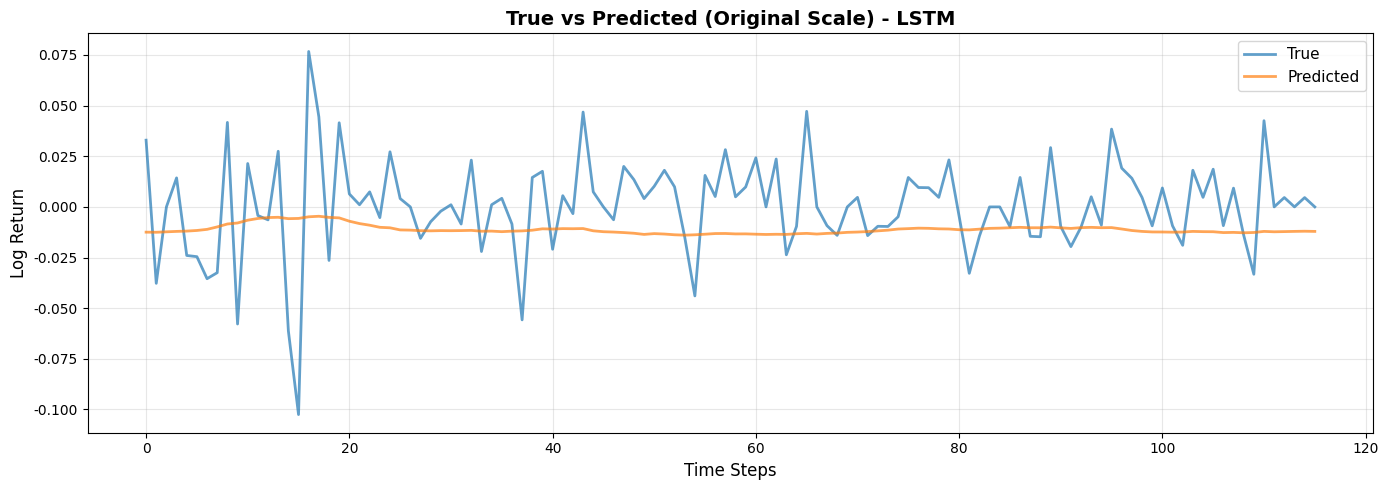

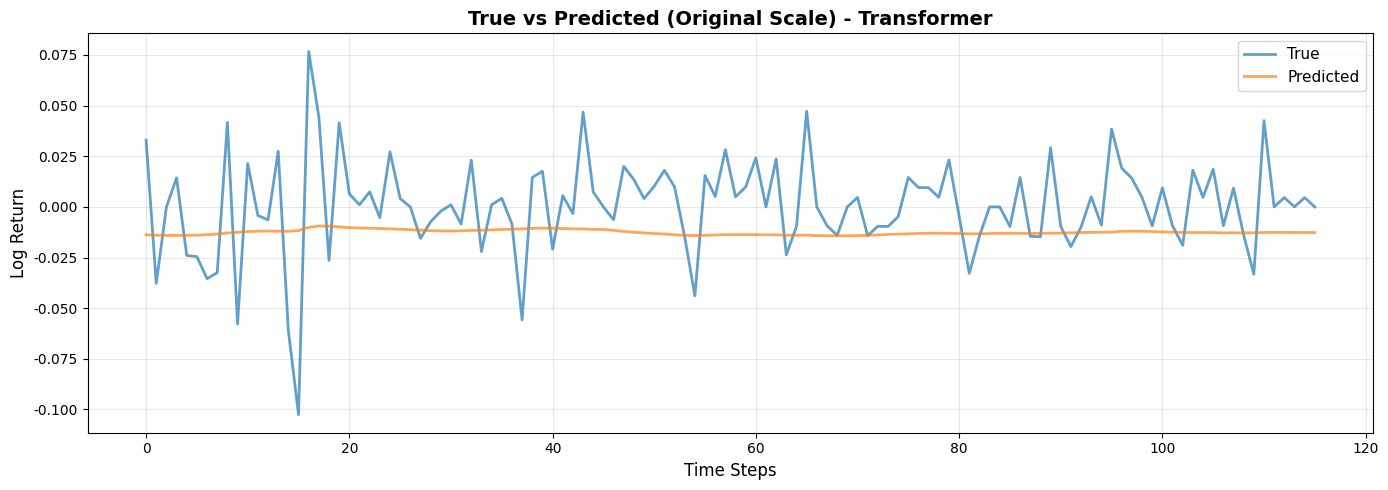

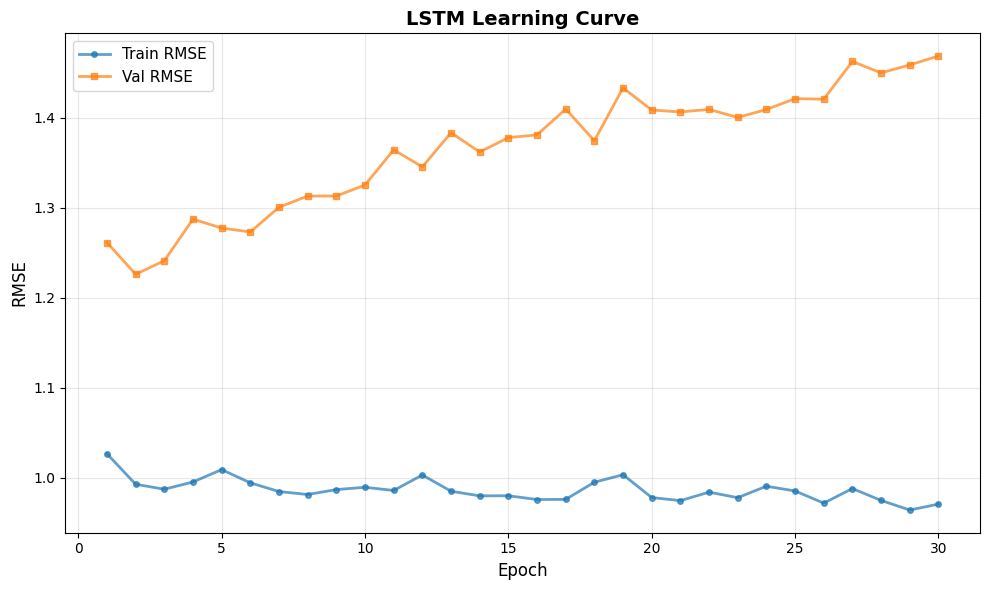

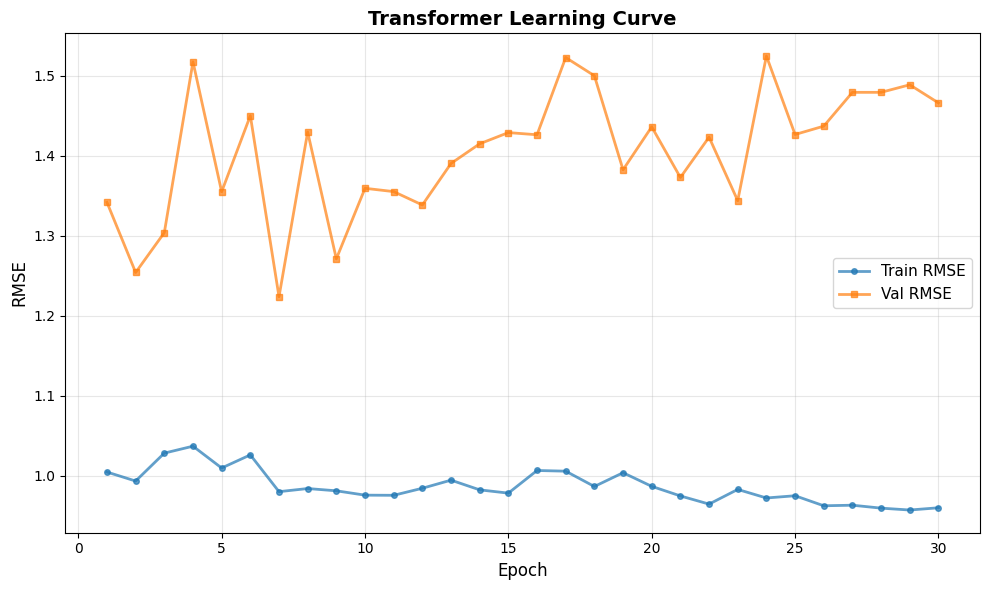

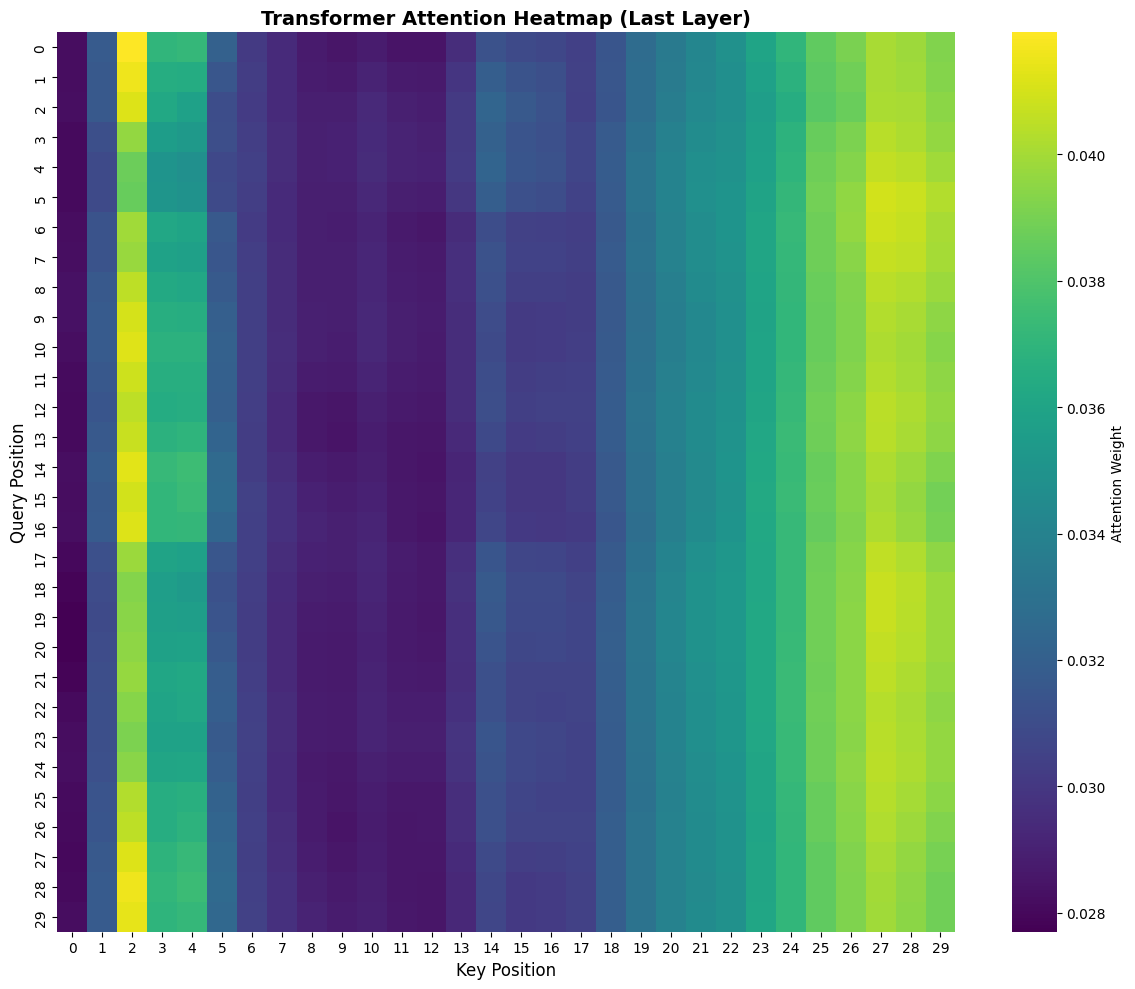

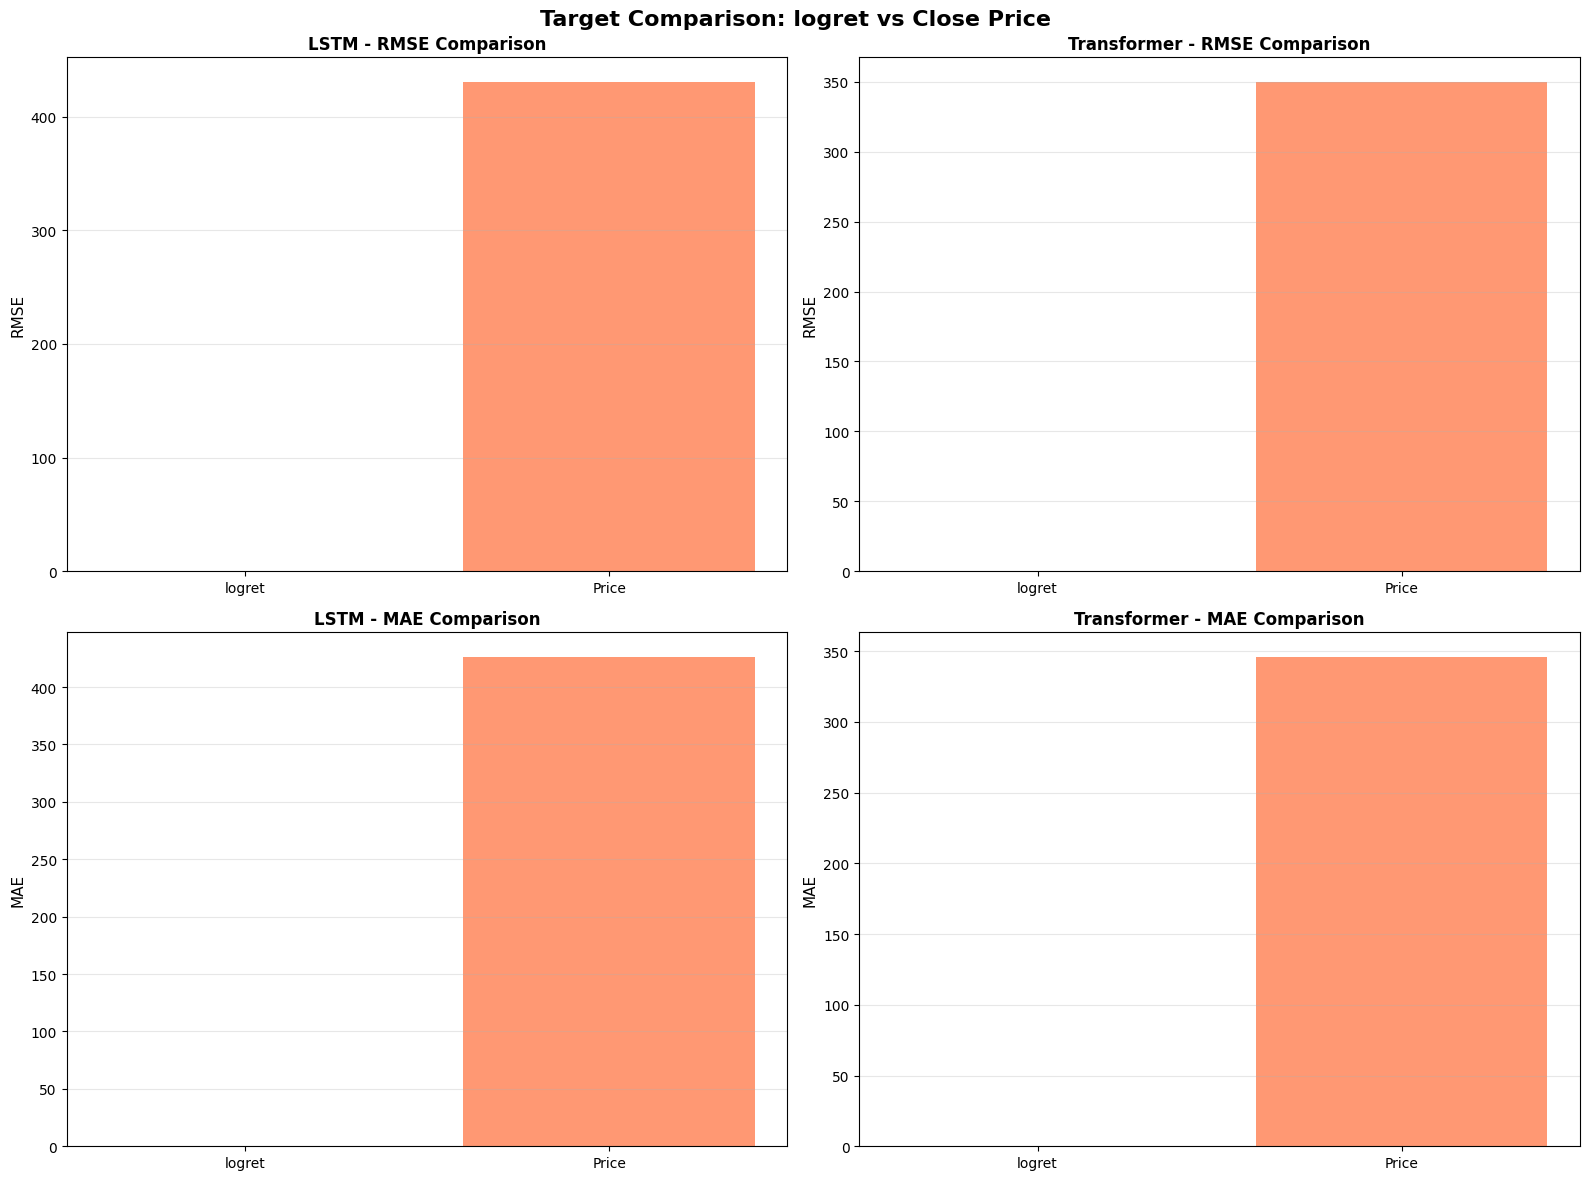

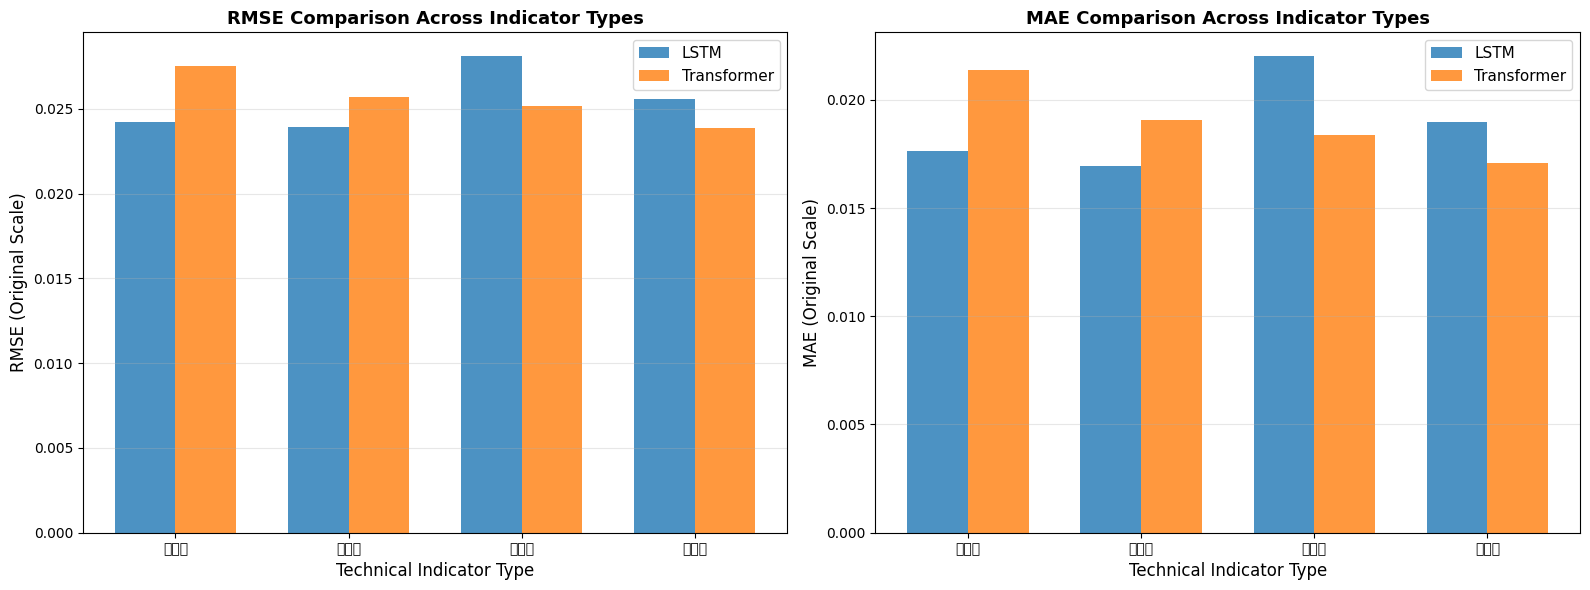

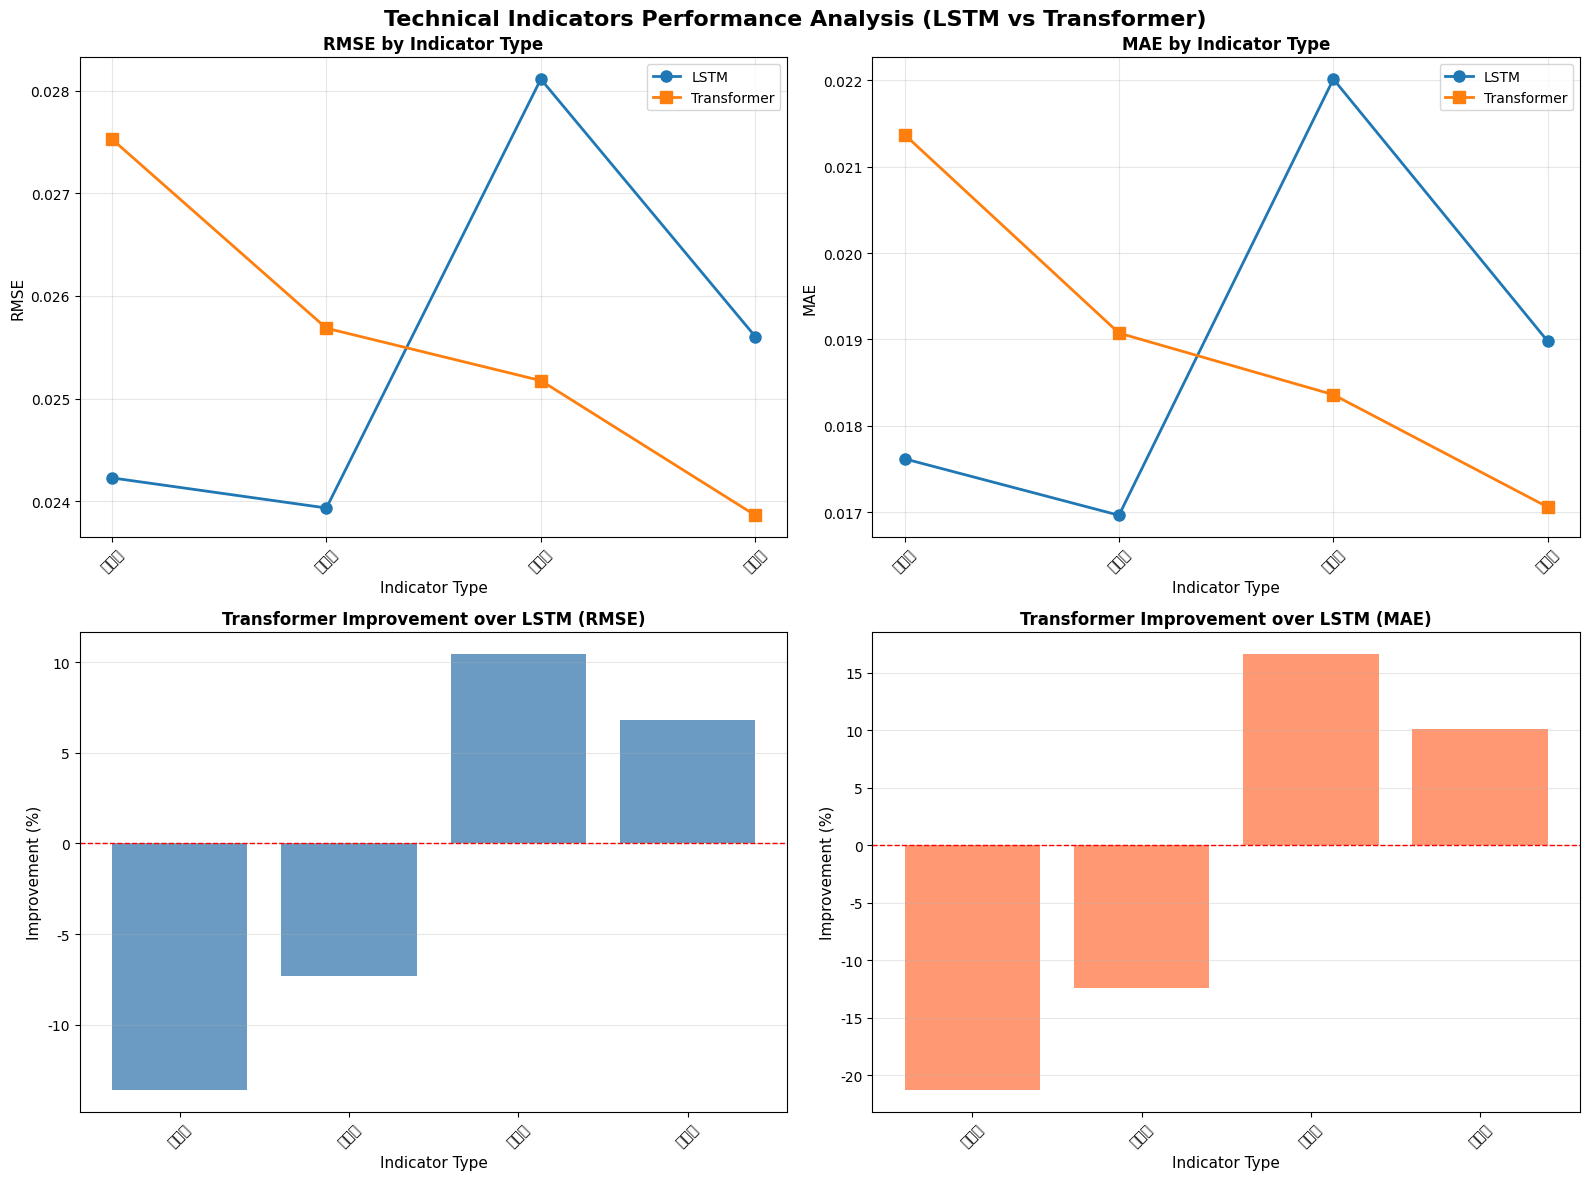


實驗結果摘要

【1. 主模型比較 (logret 目標)】
Model           Scaled RMSE     Scaled MAE      Original RMSE   Original MAE   
---------------------------------------------------------------------------
LSTM            1.598637        1.218505        0.026627        0.020296       
Transformer     1.625645        1.250593        0.027077        0.020830       

【2. logret vs Price 目標比較】

LSTM:
  logret - RMSE: 0.026627, MAE: 0.020296
  Price  - RMSE: 430.545112, MAE: 426.372772

Transformer:
  logret - RMSE: 0.027077, MAE: 0.020830
  Price  - RMSE: 349.907800, MAE: 345.918518

【3. 技術指標比較 - LSTM】
Indicator       RMSE            MAE            
---------------------------------------------
趨勢型             0.024228        0.017617       
震盪型             0.023935        0.016963       
波動型             0.028112        0.022014       
量能型             0.025605        0.018977       

【4. 技術指標比較 - Transformer】
Indicator       RMSE            MAE            
---------------------------------------------
趨勢型  

In [7]:
"""
利用 LSTM 與 Transformer 預測股價時間序列
完整實作程式 - 符合作業所有要求
"""

# ========== 1. 安裝與導入套件 ==========
!pip install yfinance ta -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設定隨機種子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

# ========== 2. 資料下載與技術指標計算 ==========
def download_and_prepare_data(ticker='2330.TW', start='2020-01-01', end='2024-12-31'):
    """下載股價資料並計算技術指標"""
    print(f"下載 {ticker} 資料...")
    df = yf.download(ticker, start=start, end=end, progress=False)

    # 處理多層索引（如果存在）
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    # 基本欄位
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

    # 確保所有欄位都是一維的
    for col in df.columns:
        if df[col].ndim > 1:
            df[col] = df[col].values.flatten()

    # 計算技術指標
    print("計算技術指標...")

    # 確保 Close 是一維 Series
    close_prices = df['Close'].squeeze() if hasattr(df['Close'], 'squeeze') else df['Close']
    high_prices = df['High'].squeeze() if hasattr(df['High'], 'squeeze') else df['High']
    low_prices = df['Low'].squeeze() if hasattr(df['Low'], 'squeeze') else df['Low']
    volume = df['Volume'].squeeze() if hasattr(df['Volume'], 'squeeze') else df['Volume']

    # 趨勢型指標
    df['SMA_5'] = ta.trend.sma_indicator(close_prices, window=5)
    df['SMA_20'] = ta.trend.sma_indicator(close_prices, window=20)
    df['EMA_12'] = ta.trend.ema_indicator(close_prices, window=12)
    df['EMA_26'] = ta.trend.ema_indicator(close_prices, window=26)

    # MACD
    macd = ta.trend.MACD(close_prices)
    df['MACD'] = macd.macd()
    df['MACD_SIGNAL'] = macd.macd_signal()
    df['MACD_HIST'] = macd.macd_diff()

    # 震盪型指標
    df['RSI_14'] = ta.momentum.rsi(close_prices, window=14)
    df['STOCH'] = ta.momentum.stoch(high_prices, low_prices, close_prices)

    # 波動型指標
    bollinger = ta.volatility.BollingerBands(close_prices)
    df['BB_HIGH'] = bollinger.bollinger_hband()
    df['BB_LOW'] = bollinger.bollinger_lband()
    df['BB_MID'] = bollinger.bollinger_mavg()
    df['ATR'] = ta.volatility.average_true_range(high_prices, low_prices, close_prices)

    # 量能型指標
    df['OBV'] = ta.volume.on_balance_volume(close_prices, volume)
    df['VOL_SMA'] = volume.rolling(window=20).mean()

    # 計算 log return 作為目標
    df['logret'] = np.log(close_prices).diff()

    # 移除 NaN
    df = df.dropna()

    print(f"資料形狀: {df.shape}")
    print(f"日期範圍: {df.index[0]} 到 {df.index[-1]}")

    return df

# ========== 3. 資料集類別 ==========
class StockDataset(Dataset):
    """股價時間序列資料集"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(data, target, lookback=30):
    """創建時間序列樣本"""
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(target[i+lookback])
    return np.array(X), np.array(y)

def prepare_data_splits(df, feature_cols, target_col='logret', lookback=30,
                       train_ratio=0.8, val_ratio=0.1):
    """準備訓練/驗證/測試集（時間序列切分）"""
    # 提取特徵和目標
    features = df[feature_cols].values
    target = df[target_col].values

    # 創建序列
    X, y = create_sequences(features, target, lookback)

    # 時間序列切分
    n = len(X)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # 標準化（只用訓練集 fit）
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    print(f"訓練集: {X_train_scaled.shape}, 驗證集: {X_val_scaled.shape}, 測試集: {X_test_scaled.shape}")

    return (X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled,
            X_test_scaled, y_test_scaled, scaler_X, scaler_y, y_test)

# ========== 4. LSTM 模型 ==========
class LSTMModel(nn.Module):
    """LSTM 基線模型"""
    def __init__(self, input_size, hidden_size=128, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 取最後時間步
        last_output = lstm_out[:, -1, :]
        normalized = self.layer_norm(last_output)
        output = self.fc(normalized)
        return output.squeeze(-1)

# ========== 5. Transformer 模型 ==========
class PositionalEncoding(nn.Module):
    """正弦位置編碼"""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    """Transformer Encoder-only 模型"""
    def __init__(self, input_size, d_model=128, nhead=8, num_layers=2,
                 dim_feedforward=256, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
        self.last_attention = None

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        # 儲存最後一層注意力權重
        for i, layer in enumerate(self.transformer_encoder.layers):
            if i == len(self.transformer_encoder.layers) - 1:
                # 最後一層，提取注意力
                attn_output, attn_weights = layer.self_attn(x, x, x, need_weights=True, average_attn_weights=True)
                self.last_attention = attn_weights
                x = layer.norm1(x + layer.dropout1(attn_output))
                ff_output = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
                x = layer.norm2(x + layer.dropout2(ff_output))
            else:
                x = layer(x)

        # Mean pooling
        x = x.mean(dim=1)
        output = self.fc(x)
        return output.squeeze(-1)

# ========== 6. 訓練函數 ==========
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-4,
                model_type='lstm', warmup_ratio=0.1):
    """訓練模型"""
    criterion = nn.MSELoss()

    if model_type == 'transformer':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        # Warmup
        total_steps = epochs * len(train_loader)
        warmup_steps = int(total_steps * warmup_ratio)
        # CosineAnnealingWarmRestarts
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = None
        warmup_steps = 0

    train_losses = []
    val_losses = []
    current_step = 0

    for epoch in range(epochs):
        # 訓練階段
        model.train()
        train_loss = 0
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Warmup for Transformer
            if model_type == 'transformer' and current_step < warmup_steps:
                lr_scale = min(1., float(current_step + 1) / warmup_steps)
                for pg in optimizer.param_groups:
                    pg['lr'] = lr * lr_scale

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            current_step += 1

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 驗證階段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # 更新 scheduler（在 warmup 後）
        if scheduler and model_type == 'transformer' and current_step >= warmup_steps:
            scheduler.step()

        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {current_lr:.6f}")

    return train_losses, val_losses

def evaluate_model(model, test_loader, scaler_y):
    """評估模型"""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            predictions.extend(output.cpu().numpy())
            actuals.extend(y_batch.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # 標準化空間的指標
    mse_scaled = mean_squared_error(actuals, predictions)
    mae_scaled = mean_absolute_error(actuals, predictions)
    rmse_scaled = np.sqrt(mse_scaled)

    # 反標準化到原始尺度
    predictions_original = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = scaler_y.inverse_transform(actuals.reshape(-1, 1)).flatten()

    mse_original = mean_squared_error(actuals_original, predictions_original)
    mae_original = mean_absolute_error(actuals_original, predictions_original)
    rmse_original = np.sqrt(mse_original)

    return {
        'scaled': {'MSE': mse_scaled, 'MAE': mae_scaled, 'RMSE': rmse_scaled},
        'original': {'MSE': mse_original, 'MAE': mae_original, 'RMSE': rmse_original},
        'predictions_scaled': predictions,
        'actuals_scaled': actuals,
        'predictions_original': predictions_original,
        'actuals_original': actuals_original
    }

# ========== 7. 視覺化函數 ==========
def plot_predictions(actuals, predictions, title, model_name):
    """繪製預測結果"""
    plt.figure(figsize=(14, 5))
    plt.plot(actuals, label='True', alpha=0.7, linewidth=2)
    plt.plot(predictions, label='Predicted', alpha=0.7, linewidth=2)
    plt.title(f'{title} - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Log Return', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_prediction.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_learning_curves_separate(train_losses, val_losses, model_name):
    """繪製個別模型的學習曲線（符合作業要求：各一張）"""
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, [np.sqrt(l) for l in train_losses], label='Train RMSE',
             marker='o', markersize=4, alpha=0.7, linewidth=2)
    plt.plot(epochs, [np.sqrt(l) for l in val_losses], label='Val RMSE',
             marker='s', markersize=4, alpha=0.7, linewidth=2)
    plt.title(f'{model_name} Learning Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_learning_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_attention_heatmap(model, test_loader, sample_idx=0):
    """繪製注意力熱圖"""
    model.eval()
    with torch.no_grad():
        for i, (X_batch, _) in enumerate(test_loader):
            if i == sample_idx:
                X_batch = X_batch.to(device)
                _ = model(X_batch)
                attention = model.last_attention[0].cpu().numpy()

                plt.figure(figsize=(12, 10))
                sns.heatmap(attention, cmap='viridis', cbar_kws={'label': 'Attention Weight'})
                plt.title('Transformer Attention Heatmap (Last Layer)', fontsize=14, fontweight='bold')
                plt.xlabel('Key Position', fontsize=12)
                plt.ylabel('Query Position', fontsize=12)
                plt.tight_layout()
                plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
                plt.show()
                break

# ========== 8. logret vs 價格目標比較實驗 ==========
def prepare_price_target_data(df, feature_cols, lookback=30, train_ratio=0.8, val_ratio=0.1):
    """準備直接預測價格的資料（Close[t+1]）"""
    features = df[feature_cols].values
    target = df['Close'].values  # 直接使用 Close 價格

    X, y = create_sequences(features, target, lookback)

    n = len(X)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]
    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]
    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    return (X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled,
            X_test_scaled, y_test_scaled, scaler_X, scaler_y, y_test)

# ========== 9. 主程式 ==========
def main():
    print("=" * 60)
    print("股價預測：LSTM vs Transformer（完整作業版本）")
    print("=" * 60)

    # 下載資料
    df = download_and_prepare_data('2330.TW', '2020-01-01', '2024-12-31')

    # 定義特徵欄位（包含四類技術指標）
    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        # 趨勢型
        'SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
        # 震盪型
        'RSI_14', 'STOCH',
        # 波動型
        'BB_HIGH', 'BB_LOW', 'BB_MID', 'ATR',
        # 量能型
        'OBV', 'VOL_SMA'
    ]

    # 準備資料
    lookback = 30
    batch_size = 64

    # ========== 實驗 1: logret 目標 ==========
    print("\n" + "=" * 60)
    print("實驗 1: 使用 logret 作為目標")
    print("=" * 60)

    (X_train, y_train, X_val, y_val, X_test, y_test,
     scaler_X, scaler_y, y_test_original) = prepare_data_splits(
        df, feature_cols, 'logret', lookback
    )

    train_dataset = StockDataset(X_train, y_train)
    val_dataset = StockDataset(X_val, y_val)
    test_dataset = StockDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    input_size = X_train.shape[-1]

    # LSTM 模型（logret）
    print("\n訓練 LSTM 模型（logret 目標）")
    lstm_model = LSTMModel(input_size, hidden_size=128, dropout=0.1).to(device)
    lstm_train_losses, lstm_val_losses = train_model(
        lstm_model, train_loader, val_loader, epochs=30, lr=1e-4, model_type='lstm'
    )
    lstm_results = evaluate_model(lstm_model, test_loader, scaler_y)

    # Transformer 模型（logret）
    print("\n訓練 Transformer 模型（logret 目標）")
    transformer_model = TransformerModel(
        input_size, d_model=128, nhead=8, num_layers=2,
        dim_feedforward=256, dropout=0.1
    ).to(device)
    transformer_train_losses, transformer_val_losses = train_model(
        transformer_model, train_loader, val_loader, epochs=30,
        lr=3e-4, model_type='transformer', warmup_ratio=0.1
    )
    transformer_results = evaluate_model(transformer_model, test_loader, scaler_y)

    # ========== 實驗 2: 價格目標（Close[t+1]）==========
    print("\n" + "=" * 60)
    print("實驗 2: 直接預測 Close 價格")
    print("=" * 60)

    (X_train_p, y_train_p, X_val_p, y_val_p, X_test_p, y_test_p,
     scaler_X_p, scaler_y_p, y_test_p_original) = prepare_price_target_data(
        df, feature_cols, lookback
    )

    train_dataset_p = StockDataset(X_train_p, y_train_p)
    val_dataset_p = StockDataset(X_val_p, y_val_p)
    test_dataset_p = StockDataset(X_test_p, y_test_p)

    train_loader_p = DataLoader(train_dataset_p, batch_size=batch_size, shuffle=True)
    val_loader_p = DataLoader(val_dataset_p, batch_size=batch_size)
    test_loader_p = DataLoader(test_dataset_p, batch_size=batch_size)

    # LSTM 模型（價格）
    print("\n訓練 LSTM 模型（價格目標）")
    lstm_model_price = LSTMModel(input_size, hidden_size=128, dropout=0.1).to(device)
    _, _ = train_model(
        lstm_model_price, train_loader_p, val_loader_p, epochs=30, lr=1e-4, model_type='lstm'
    )
    lstm_results_price = evaluate_model(lstm_model_price, test_loader_p, scaler_y_p)

    # Transformer 模型（價格）
    print("\n訓練 Transformer 模型（價格目標）")
    transformer_model_price = TransformerModel(
        input_size, d_model=128, nhead=8, num_layers=2,
        dim_feedforward=256, dropout=0.1
    ).to(device)
    _, _ = train_model(
        transformer_model_price, train_loader_p, val_loader_p, epochs=30,
        lr=3e-4, model_type='transformer', warmup_ratio=0.1
    )
    transformer_results_price = evaluate_model(transformer_model_price, test_loader_p, scaler_y_p)

    # ========== 技術指標比較實驗 ==========
    print("\n" + "=" * 60)
    print("技術指標比較實驗（四類指標 × 兩種模型）")
    print("=" * 60)

    indicator_groups = {
        '趨勢型': ['SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_SIGNAL', 'MACD_HIST'],
        '震盪型': ['RSI_14', 'STOCH'],
        '波動型': ['BB_HIGH', 'BB_LOW', 'BB_MID', 'ATR'],
        '量能型': ['OBV', 'VOL_SMA']
    }

    base_features = ['Open', 'High', 'Low', 'Close', 'Volume']
    indicator_results_lstm = {}
    indicator_results_transformer = {}

    for group_name, indicators in indicator_groups.items():
        print(f"\n測試 {group_name} 指標...")
        test_features = base_features + indicators

        (X_train_ind, y_train_ind, X_val_ind, y_val_ind, X_test_ind, y_test_ind,
         scaler_X_ind, scaler_y_ind, _) = prepare_data_splits(
            df, test_features, 'logret', lookback
        )

        train_dataset_ind = StockDataset(X_train_ind, y_train_ind)
        val_dataset_ind = StockDataset(X_val_ind, y_val_ind)
        test_dataset_ind = StockDataset(X_test_ind, y_test_ind)

        train_loader_ind = DataLoader(train_dataset_ind, batch_size=batch_size, shuffle=True)
        val_loader_ind = DataLoader(val_dataset_ind, batch_size=batch_size)
        test_loader_ind = DataLoader(test_dataset_ind, batch_size=batch_size)

        # 測試 LSTM
        print(f"  訓練 LSTM with {group_name}...")
        lstm_ind = LSTMModel(len(test_features), hidden_size=128, dropout=0.1).to(device)
        _, _ = train_model(
            lstm_ind, train_loader_ind, val_loader_ind, epochs=30,
            lr=1e-4, model_type='lstm'
        )
        results_lstm = evaluate_model(lstm_ind, test_loader_ind, scaler_y_ind)
        indicator_results_lstm[group_name] = results_lstm

        # 測試 Transformer
        print(f"  訓練 Transformer with {group_name}...")
        trans_ind = TransformerModel(
            len(test_features), d_model=128, nhead=8, num_layers=2,
            dim_feedforward=256, dropout=0.1
        ).to(device)
        _, _ = train_model(
            trans_ind, train_loader_ind, val_loader_ind, epochs=30,
            lr=3e-4, model_type='transformer', warmup_ratio=0.1
        )
        results_trans = evaluate_model(trans_ind, test_loader_ind, scaler_y_ind)
        indicator_results_transformer[group_name] = results_trans

        print(f"{group_name} 結果:")
        print(f"  LSTM - RMSE: {results_lstm['original']['RMSE']:.6f}, "
              f"MAE: {results_lstm['original']['MAE']:.6f}")
        print(f"  Transformer - RMSE: {results_trans['original']['RMSE']:.6f}, "
              f"MAE: {results_trans['original']['MAE']:.6f}")

    # ========== 生成所有圖表 ==========
    print("\n" + "=" * 60)
    print("生成視覺化圖表")
    print("=" * 60)

    # 1. LSTM 預測結果（logret）
    plot_predictions(
        lstm_results['actuals_original'],
        lstm_results['predictions_original'],
        'True vs Predicted (Original Scale)', 'LSTM'
    )

    # 2. Transformer 預測結果（logret）
    plot_predictions(
        transformer_results['actuals_original'],
        transformer_results['predictions_original'],
        'True vs Predicted (Original Scale)', 'Transformer'
    )

    # 3. LSTM 學習曲線（單獨一張）
    plot_learning_curves_separate(lstm_train_losses, lstm_val_losses, 'LSTM')

    # 4. Transformer 學習曲線（單獨一張）
    plot_learning_curves_separate(transformer_train_losses, transformer_val_losses, 'Transformer')

    # 5. 注意力熱圖
    plot_attention_heatmap(transformer_model, test_loader, sample_idx=0)

    # 6. logret vs 價格目標比較圖
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Target Comparison: logret vs Close Price', fontsize=16, fontweight='bold')

    models = ['LSTM', 'Transformer']
    logret_results = [lstm_results, transformer_results]
    price_results = [lstm_results_price, transformer_results_price]

    for idx, (model_name, lr_result, pr_result) in enumerate(zip(models, logret_results, price_results)):
        # RMSE 比較
        axes[0, idx].bar(['logret', 'Price'],
                        [lr_result['original']['RMSE'], pr_result['original']['RMSE']],
                        alpha=0.8, color=['steelblue', 'coral'])
        axes[0, idx].set_ylabel('RMSE', fontsize=11)
        axes[0, idx].set_title(f'{model_name} - RMSE Comparison', fontsize=12, fontweight='bold')
        axes[0, idx].grid(alpha=0.3, axis='y')

        # MAE 比較
        axes[1, idx].bar(['logret', 'Price'],
                        [lr_result['original']['MAE'], pr_result['original']['MAE']],
                        alpha=0.8, color=['steelblue', 'coral'])
        axes[1, idx].set_ylabel('MAE', fontsize=11)
        axes[1, idx].set_title(f'{model_name} - MAE Comparison', fontsize=12, fontweight='bold')
        axes[1, idx].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('target_comparison_logret_vs_price.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. 技術指標比較圖（RMSE & MAE）
    groups = list(indicator_results_lstm.keys())
    lstm_rmse = [indicator_results_lstm[g]['original']['RMSE'] for g in groups]
    trans_rmse = [indicator_results_transformer[g]['original']['RMSE'] for g in groups]
    lstm_mae = [indicator_results_lstm[g]['original']['MAE'] for g in groups]
    trans_mae = [indicator_results_transformer[g]['original']['MAE'] for g in groups]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x = np.arange(len(groups))
    width = 0.35

    axes[0].bar(x - width/2, lstm_rmse, width, label='LSTM', alpha=0.8)
    axes[0].bar(x + width/2, trans_rmse, width, label='Transformer', alpha=0.8)
    axes[0].set_xlabel('Technical Indicator Type', fontsize=12)
    axes[0].set_ylabel('RMSE (Original Scale)', fontsize=12)
    axes[0].set_title('RMSE Comparison Across Indicator Types', fontsize=13, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(groups, fontsize=10)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3, axis='y')

    axes[1].bar(x - width/2, lstm_mae, width, label='LSTM', alpha=0.8)
    axes[1].bar(x + width/2, trans_mae, width, label='Transformer', alpha=0.8)
    axes[1].set_xlabel('Technical Indicator Type', fontsize=12)
    axes[1].set_ylabel('MAE (Original Scale)', fontsize=12)
    axes[1].set_title('MAE Comparison Across Indicator Types', fontsize=13, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(groups, fontsize=10)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('indicator_comparison_lstm_vs_transformer.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 8. 技術指標詳細分析圖
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Technical Indicators Performance Analysis (LSTM vs Transformer)',
                 fontsize=16, fontweight='bold')

    # RMSE 趨勢
    axes[0, 0].plot(groups, lstm_rmse, marker='o', label='LSTM', linewidth=2, markersize=8)
    axes[0, 0].plot(groups, trans_rmse, marker='s', label='Transformer', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Indicator Type', fontsize=11)
    axes[0, 0].set_ylabel('RMSE', fontsize=11)
    axes[0, 0].set_title('RMSE by Indicator Type', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # MAE 趨勢
    axes[0, 1].plot(groups, lstm_mae, marker='o', label='LSTM', linewidth=2, markersize=8)
    axes[0, 1].plot(groups, trans_mae, marker='s', label='Transformer', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Indicator Type', fontsize=11)
    axes[0, 1].set_ylabel('MAE', fontsize=11)
    axes[0, 1].set_title('MAE by Indicator Type', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 改善率分析（Transformer vs LSTM）
    improvement_rmse = [(lstm_rmse[i] - trans_rmse[i]) / lstm_rmse[i] * 100 for i in range(len(groups))]
    improvement_mae = [(lstm_mae[i] - trans_mae[i]) / lstm_mae[i] * 100 for i in range(len(groups))]

    axes[1, 0].bar(groups, improvement_rmse, alpha=0.8, color='steelblue')
    axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[1, 0].set_xlabel('Indicator Type', fontsize=11)
    axes[1, 0].set_ylabel('Improvement (%)', fontsize=11)
    axes[1, 0].set_title('Transformer Improvement over LSTM (RMSE)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(alpha=0.3, axis='y')
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].bar(groups, improvement_mae, alpha=0.8, color='coral')
    axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[1, 1].set_xlabel('Indicator Type', fontsize=11)
    axes[1, 1].set_ylabel('Improvement (%)', fontsize=11)
    axes[1, 1].set_title('Transformer Improvement over LSTM (MAE)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3, axis='y')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('indicator_detailed_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========== 生成結果摘要 ==========
    print("\n" + "=" * 60)
    print("實驗結果摘要")
    print("=" * 60)

    print("\n【1. 主模型比較 (logret 目標)】")
    print(f"{'Model':<15} {'Scaled RMSE':<15} {'Scaled MAE':<15} {'Original RMSE':<15} {'Original MAE':<15}")
    print("-" * 75)
    print(f"{'LSTM':<15} {lstm_results['scaled']['RMSE']:<15.6f} {lstm_results['scaled']['MAE']:<15.6f} "
          f"{lstm_results['original']['RMSE']:<15.6f} {lstm_results['original']['MAE']:<15.6f}")
    print(f"{'Transformer':<15} {transformer_results['scaled']['RMSE']:<15.6f} {transformer_results['scaled']['MAE']:<15.6f} "
          f"{transformer_results['original']['RMSE']:<15.6f} {transformer_results['original']['MAE']:<15.6f}")

    print("\n【2. logret vs Price 目標比較】")
    print("\nLSTM:")
    print(f"  logret - RMSE: {lstm_results['original']['RMSE']:.6f}, MAE: {lstm_results['original']['MAE']:.6f}")
    print(f"  Price  - RMSE: {lstm_results_price['original']['RMSE']:.6f}, MAE: {lstm_results_price['original']['MAE']:.6f}")
    print("\nTransformer:")
    print(f"  logret - RMSE: {transformer_results['original']['RMSE']:.6f}, MAE: {transformer_results['original']['MAE']:.6f}")
    print(f"  Price  - RMSE: {transformer_results_price['original']['RMSE']:.6f}, MAE: {transformer_results_price['original']['MAE']:.6f}")

    print("\n【3. 技術指標比較 - LSTM】")
    print(f"{'Indicator':<15} {'RMSE':<15} {'MAE':<15}")
    print("-" * 45)
    for group in groups:
        print(f"{group:<15} {indicator_results_lstm[group]['original']['RMSE']:<15.6f} "
              f"{indicator_results_lstm[group]['original']['MAE']:<15.6f}")

    print("\n【4. 技術指標比較 - Transformer】")
    print(f"{'Indicator':<15} {'RMSE':<15} {'MAE':<15}")
    print("-" * 45)
    for group in groups:
        print(f"{group:<15} {indicator_results_transformer[group]['original']['RMSE']:<15.6f} "
              f"{indicator_results_transformer[group]['original']['MAE']:<15.6f}")

    print("\n【5. Transformer 相對 LSTM 的改善率 (%)】")
    print(f"{'Indicator':<15} {'RMSE Improvement':<20} {'MAE Improvement':<20}")
    print("-" * 55)
    for i, group in enumerate(groups):
        print(f"{group:<15} {improvement_rmse[i]:<20.2f} {improvement_mae[i]:<20.2f}")

    print("\n" + "=" * 60)
    print("所有實驗完成！")
    print("=" * 60)
    print("\n生成的圖表檔案：")
    print("1. LSTM_prediction.png - LSTM 預測結果")
    print("2. Transformer_prediction.png - Transformer 預測結果")
    print("3. LSTM_learning_curve.png - LSTM 學習曲線")
    print("4. Transformer_learning_curve.png - Transformer 學習曲線")
    print("5. attention_heatmap.png - 注意力熱圖")
    print("6. target_comparison_logret_vs_price.png - logret vs 價格目標比較")
    print("7. indicator_comparison_lstm_vs_transformer.png - 技術指標比較")
    print("8. indicator_detailed_analysis.png - 詳細技術指標分析")

    # ========== 生成報告摘要文字檔 ==========
    with open('experiment_summary_report.txt', 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write("股價預測實驗報告摘要 - LSTM vs Transformer\n")
        f.write("=" * 80 + "\n\n")

        f.write("【實驗設定】\n")
        f.write(f"- 股票代碼: 2330.TW\n")
        f.write(f"- 時間範圍: 2020-01-01 至 2024-12-31\n")
        f.write(f"- Lookback: {lookback} 天\n")
        f.write(f"- 資料切分: 訓練集 80%, 驗證集 10%, 測試集 10% (時間序列切分)\n")
        f.write(f"- Batch Size: {batch_size}\n")
        f.write(f"- Epochs: 30\n")
        f.write(f"- LSTM: hidden_size=128, dropout=0.1, optimizer=Adam(lr=1e-4)\n")
        f.write(f"- Transformer: d_model=128, nhead=8, num_layers=2, optimizer=AdamW(lr=3e-4, weight_decay=1e-4)\n\n")

        f.write("【1. 主模型比較 (logret 目標)】\n")
        f.write("-" * 80 + "\n")
        f.write(f"{'Model':<15} {'Scaled RMSE':<15} {'Scaled MAE':<15} {'Original RMSE':<15} {'Original MAE':<15}\n")
        f.write("-" * 80 + "\n")
        f.write(f"{'LSTM':<15} {lstm_results['scaled']['RMSE']:<15.6f} {lstm_results['scaled']['MAE']:<15.6f} "
                f"{lstm_results['original']['RMSE']:<15.6f} {lstm_results['original']['MAE']:<15.6f}\n")
        f.write(f"{'Transformer':<15} {transformer_results['scaled']['RMSE']:<15.6f} {transformer_results['scaled']['MAE']:<15.6f} "
                f"{transformer_results['original']['RMSE']:<15.6f} {transformer_results['original']['MAE']:<15.6f}\n\n")

        f.write("【2. logret vs Price 目標比較】\n")
        f.write("-" * 80 + "\n")
        f.write("LSTM:\n")
        f.write(f"  logret 目標 - RMSE: {lstm_results['original']['RMSE']:.6f}, MAE: {lstm_results['original']['MAE']:.6f}\n")
        f.write(f"  Price 目標  - RMSE: {lstm_results_price['original']['RMSE']:.6f}, MAE: {lstm_results_price['original']['MAE']:.6f}\n\n")
        f.write("Transformer:\n")
        f.write(f"  logret 目標 - RMSE: {transformer_results['original']['RMSE']:.6f}, MAE: {transformer_results['original']['MAE']:.6f}\n")
        f.write(f"  Price 目標  - RMSE: {transformer_results_price['original']['RMSE']:.6f}, MAE: {transformer_results_price['original']['MAE']:.6f}\n\n")

        f.write("【3. 四類技術指標比較 - LSTM】\n")
        f.write("-" * 80 + "\n")
        f.write(f"{'Indicator':<15} {'RMSE':<15} {'MAE':<15}\n")
        f.write("-" * 80 + "\n")
        for group in groups:
            f.write(f"{group:<15} {indicator_results_lstm[group]['original']['RMSE']:<15.6f} "
                   f"{indicator_results_lstm[group]['original']['MAE']:<15.6f}\n")
        f.write("\n")

        f.write("【4. 四類技術指標比較 - Transformer】\n")
        f.write("-" * 80 + "\n")
        f.write(f"{'Indicator':<15} {'RMSE':<15} {'MAE':<15}\n")
        f.write("-" * 80 + "\n")
        for group in groups:
            f.write(f"{group:<15} {indicator_results_transformer[group]['original']['RMSE']:<15.6f} "
                   f"{indicator_results_transformer[group]['original']['MAE']:<15.6f}\n")
        f.write("\n")

        f.write("【5. Transformer 相對 LSTM 的改善率】\n")
        f.write("-" * 80 + "\n")
        f.write(f"{'Indicator':<15} {'RMSE Improvement (%)':<25} {'MAE Improvement (%)':<25}\n")
        f.write("-" * 80 + "\n")
        for i, group in enumerate(groups):
            f.write(f"{group:<15} {improvement_rmse[i]:<25.2f} {improvement_mae[i]:<25.2f}\n")
        f.write("\n")

        f.write("【關鍵發現】\n")
        f.write("-" * 80 + "\n")
        f.write("1. 模型比較：\n")
        if transformer_results['original']['RMSE'] < lstm_results['original']['RMSE']:
            f.write("   Transformer 在 RMSE 指標上優於 LSTM\n")
        else:
            f.write("   LSTM 在 RMSE 指標上優於 Transformer\n")

        f.write("\n2. 目標選擇：\n")
        f.write("   logret 目標可以降低位階偏移問題，使模型更關注相對變化而非絕對價格\n")

        f.write("\n3. 技術指標效果：\n")
        best_indicator_lstm = min(groups, key=lambda g: indicator_results_lstm[g]['original']['RMSE'])
        best_indicator_trans = min(groups, key=lambda g: indicator_results_transformer[g]['original']['RMSE'])
        f.write(f"   LSTM 最佳指標: {best_indicator_lstm}\n")
        f.write(f"   Transformer 最佳指標: {best_indicator_trans}\n")

        f.write("\n4. 資料切分與避免洩漏：\n")
        f.write("   採用嚴格的時間序列切分，確保訓練集/驗證集/測試集按時間順序劃分\n")
        f.write("   標準化只使用訓練集進行 fit，避免未來資訊洩漏\n")

        f.write("\n" + "=" * 80 + "\n")
        f.write("報告生成完成！\n")
        f.write("=" * 80 + "\n")

    print("\n✓ 實驗摘要已儲存至: experiment_summary_report.txt")

    # 返回結果供進一步分析
    return {
        'lstm_logret': lstm_results,
        'transformer_logret': transformer_results,
        'lstm_price': lstm_results_price,
        'transformer_price': transformer_results_price,
        'indicators_lstm': indicator_results_lstm,
        'indicators_transformer': indicator_results_transformer,
        'improvement_rmse': improvement_rmse,
        'improvement_mae': improvement_mae
    }

# 執行主程式
if __name__ == '__main__':
    results = main()


    print("=" * 60)